# 05 Results Summary

This notebook turns the analysis into the story of the project.

It answers the question: **What did we learn about human skill acquisition?**

The previous notebooks computed the metrics. This notebook interprets them.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "data" / "results").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.learning_models import power_law, exponential
from src.visualization import plot_model_fits, plot_dfa_scaling

processed_dir = ROOT / "data" / "processed"
results_dir = ROOT / "data" / "results"
figures_dir = results_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

model_comparison_path = results_dir / "model_comparison.csv"
fit_parameters_path = results_dir / "fit_parameters.csv"
dfa_results_path = results_dir / "dfa_results.csv"
distribution_summary_path = results_dir / "distribution_summary.csv"
variability_comparison_path = results_dir / "variability_comparison.csv"
player_trajectories_path = processed_dir / "player_trajectories.csv"

required_paths = {
    "model_comparison": model_comparison_path,
    "fit_parameters": fit_parameters_path,
    "dfa_results": dfa_results_path,
    "distribution_summary": distribution_summary_path,
    "variability_comparison": variability_comparison_path,
    "player_trajectories": player_trajectories_path,
}

for name, path in required_paths.items():
    print(f"{name}: {path}")
    if not path.exists():
        raise FileNotFoundError(f"Missing required input: {path}")

model_comparison = pd.read_csv(model_comparison_path)
fit_parameters = pd.read_csv(fit_parameters_path)
dfa_results = pd.read_csv(dfa_results_path)
distribution_summary = pd.read_csv(distribution_summary_path)
variability_comparison = pd.read_csv(variability_comparison_path)
player_trajectories = pd.read_csv(player_trajectories_path, parse_dates=["competition_date"])

display(model_comparison.head())
display(dfa_results.head())
display(distribution_summary)
display(variability_comparison.head())

model_comparison: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\model_comparison.csv
fit_parameters: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\fit_parameters.csv
dfa_results: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\dfa_results.csv
distribution_summary: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\distribution_summary.csv
variability_comparison: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\variability_comparison.csv
player_trajectories: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\processed\player_trajectories.csv


,person_id,person_name,winner,winner_bic,power_rss,power_r2,power_aic,power_bic,exp_rss,exp_r2,exp_aic,exp_bic,delta_aic,delta_aic_abs,delta_aic_interpretation,delta_bic
0,2012PARK03,Max Park,power_law,power_law,171.947481,0.911158,-782.328523,-769.053916,214.154651,0.889351,-646.891262,-633.616655,135.437261,135.437261,very strong support for power law,135.437261
1,2010HULL01,Katie Hull,power_law,power_law,309.952179,0.700053,-535.413288,-521.829414,469.509143,0.545647,-251.368779,-237.784905,284.044508,284.044508,very strong support for power law,284.044508
2,2012MAHV01,Paul Mahvi,power_law,power_law,335.022308,0.902168,-511.555846,-497.898323,595.035912,0.826240,-108.884175,-95.226651,402.671671,402.671671,very strong support for power law,402.671671
3,2014ZAKR01,Karol Zakrzewski,power_law,power_law,306.563248,0.651140,-479.006361,-465.584689,364.217601,0.585532,-367.338203,-353.916531,111.668158,111.668158,very strong support for power law,111.668158
4,2013WALL03,Daniel Wallin,power_law,power_law,374.930297,0.750799,-448.991862,-435.291845,395.034940,0.737436,-411.853430,-398.153413,37.138432,37.138432,very strong support for power law,37.138432


,person_id,person_name,model,analysis_model,n_obs,hurst,intercept,dfa_r2,noise_type
0,2012PARK03,Max Park,power_law,power_law,617,0.904503,-3.092542,0.978295,persistent
1,2011EDUA01,Eduard Esteban García Domínguez,power_law,power_law,860,0.748138,-1.812402,0.953242,persistent
2,2014ZAKR01,Karol Zakrzewski,power_law,power_law,648,0.677807,-2.215673,0.988874,persistent
3,2010ROSE03,Dennis Rosero,power_law,power_law,759,0.655715,-1.780547,0.991307,persistent
4,2013WALL03,Daniel Wallin,power_law,power_law,711,0.652072,-2.098261,0.978457,persistent


,metric,value
0,players_analyzed,10.000000
1,mean_std_early,3.135746
2,mean_std_late,0.688054
3,mean_std_ratio,0.266839
4,mean_variability_reduction_pct,0.733161
5,share_with_reduced_variability,1.000000
6,paired_t_stat,3.980065
7,paired_t_pvalue,0.003205
8,wilcoxon_stat,0.000000
9,wilcoxon_pvalue,0.001953


,person_id,person_name,n_obs,phase_n,mean_early,mean_late,std_early,std_late,std_ratio,variability_reduction_pct,skewness_early,skewness_late,kurtosis_early,kurtosis_late
0,2011EDUA01,Eduard Esteban García Domínguez,860,215,15.223721,12.883442,8.417348,0.969133,0.115135,0.884865,13.084238,0.753466,183.377479,1.099515
1,2012PARK03,Max Park,617,154,8.513247,5.708701,2.607982,0.400938,0.153735,0.846265,2.034403,1.623096,4.571006,6.129649
2,2012MAHV01,Paul Mahvi,701,175,10.701714,8.097314,3.743955,0.587667,0.156964,0.843036,4.154653,0.551174,23.726398,0.671653
3,2009LIUE01,Evan Liu,700,175,12.830057,9.010343,3.794821,0.765819,0.201806,0.798194,4.761485,-0.004741,32.823985,0.611709
4,2009PROV01,Matteo Provasi,750,187,15.043422,11.298021,3.471326,0.751403,0.216460,0.783540,4.051347,0.651517,21.906316,1.141853


## Research Question 1

Power law vs exponential learning curves.

In [2]:
power_wins = (model_comparison["winner"] == "power_law").sum()
exponential_wins = (model_comparison["winner"] == "exponential").sum()
total_players = len(model_comparison)
power_win_rate = power_wins / total_players if total_players else float("nan")

rq1_table = pd.DataFrame([
    {"Metric": "Players analyzed", "Value": total_players},
    {"Metric": "Power-law wins", "Value": power_wins},
    {"Metric": "Exponential wins", "Value": exponential_wins},
    {"Metric": "Power-law win rate", "Value": power_win_rate},
    {"Metric": "Mean power-law R²", "Value": model_comparison["power_r2"].mean()},
    {"Metric": "Mean exponential R²", "Value": model_comparison["exp_r2"].mean()},
])

display(rq1_table)

print("Interpretation:")
print("The power-law model outperformed the exponential model for every analyzed player, suggesting that improvement slows gradually rather than following a fixed exponential decay.")

,Metric,Value
0,Players analyzed,10.000000
1,Power-law wins,10.000000
2,Exponential wins,0.000000
3,Power-law win rate,1.000000
4,Mean power-law R²,0.790138
5,Mean exponential R²,0.713045


Interpretation:
The power-law model outperformed the exponential model for every analyzed player, suggesting that improvement slows gradually rather than following a fixed exponential decay.


## Research Question 2

Temporal structure in residuals.

In [3]:
mean_hurst = dfa_results["hurst"].mean()
median_hurst = dfa_results["hurst"].median()
persistent_share = (dfa_results["noise_type"] == "persistent").mean()

rq2_table = pd.DataFrame([
    {"Metric": "Mean Hurst", "Value": mean_hurst},
    {"Metric": "Median Hurst", "Value": median_hurst},
    {"Metric": "Persistent players", "Value": persistent_share},
    {"Metric": "Mean DFA R²", "Value": dfa_results["dfa_r2"].mean()},
])

display(rq2_table)

print("Interpretation:")
print("Residual fluctuations are strongly persistent and the DFA scaling relationship is very linear, which suggests memory-dependent learning dynamics rather than random noise.")

,Metric,Value
0,Mean Hurst,0.674039
1,Median Hurst,0.651300
2,Persistent players,1.000000
3,Mean DFA R²,0.982909


Interpretation:
Residual fluctuations are strongly persistent and the DFA scaling relationship is very linear, which suggests memory-dependent learning dynamics rather than random noise.


## Research Question 3

Distributional change near mastery.

In [4]:
mean_std_early = distribution_summary.loc[distribution_summary["metric"] == "mean_std_early", "value"].iloc[0]
mean_std_late = distribution_summary.loc[distribution_summary["metric"] == "mean_std_late", "value"].iloc[0]
mean_std_ratio = distribution_summary.loc[distribution_summary["metric"] == "mean_std_ratio", "value"].iloc[0]
mean_variability_reduction_pct = distribution_summary.loc[distribution_summary["metric"] == "mean_variability_reduction_pct", "value"].iloc[0]
wilcoxon_pvalue = distribution_summary.loc[distribution_summary["metric"] == "wilcoxon_pvalue", "value"]
wilcoxon_pvalue = float(wilcoxon_pvalue.iloc[0]) if not wilcoxon_pvalue.empty else float("nan")

rq3_table = pd.DataFrame([
    {"Metric": "Mean early SD", "Value": mean_std_early},
    {"Metric": "Mean late SD", "Value": mean_std_late},
    {"Metric": "Mean variability ratio", "Value": mean_std_ratio},
    {"Metric": "Mean variability reduction", "Value": mean_variability_reduction_pct},
    {"Metric": "Wilcoxon p-value", "Value": wilcoxon_pvalue},
])

display(rq3_table)

print("Interpretation:")
print("As players approach mastery, performance variability shrinks dramatically and the distribution becomes more concentrated.")

,Metric,Value
0,Mean early SD,3.135746
1,Mean late SD,0.688054
2,Mean variability ratio,0.266839
3,Mean variability reduction,0.733161
4,Wilcoxon p-value,0.001953


Interpretation:
As players approach mastery, performance variability shrinks dramatically and the distribution becomes more concentrated.


## Final Figures

Three report-quality figures that summarize the project.

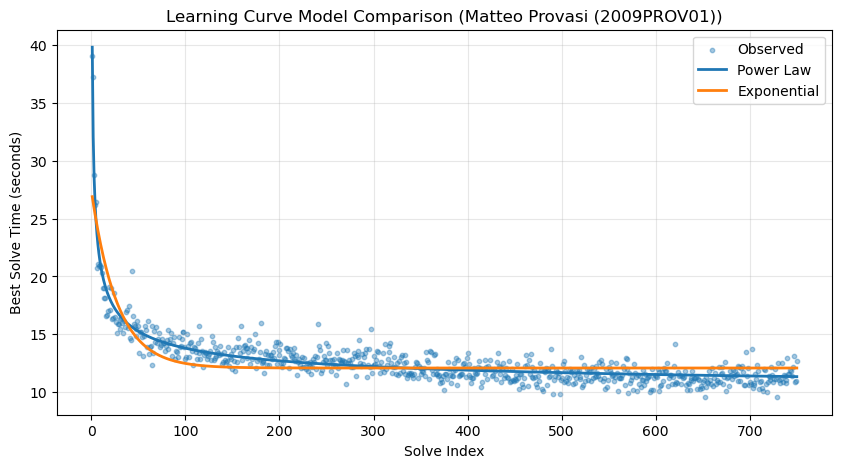

Saved Figure 1 to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\figures\figure1_best_player_learning_curve.png


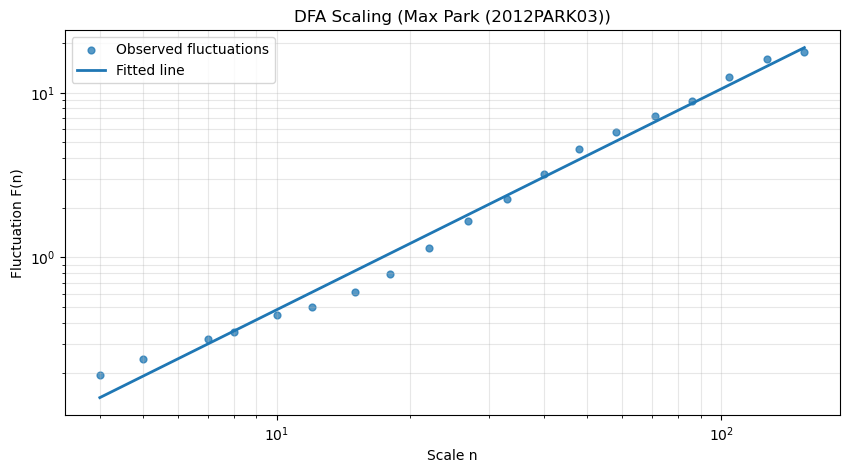

Saved Figure 2 to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\figures\figure2_dfa_scaling.png


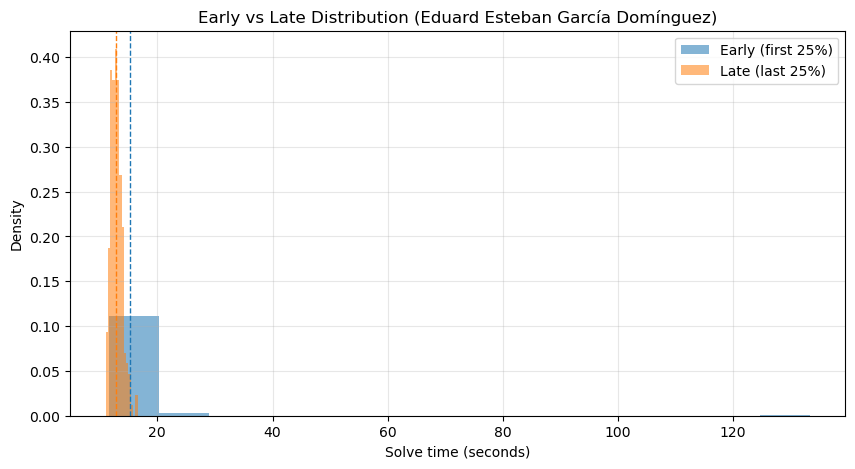

Saved Figure 3 to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\figures\figure3_early_late_distribution.png


In [7]:
example_learning_player = model_comparison.sort_values("delta_aic_abs", ascending=False).iloc[0]
learning_player_id = example_learning_player["person_id"]
learning_player_name = example_learning_player["person_name"]

player_trajectory = player_trajectories.loc[player_trajectories["person_id"] == learning_player_id].copy()
player_trajectory = player_trajectory.sort_values("seq_index").reset_index(drop=True)
x = player_trajectory["seq_index"].to_numpy(dtype=float)
y = player_trajectory["average_seconds"].to_numpy(dtype=float)

power_row = fit_parameters[(fit_parameters["person_id"] == learning_player_id) & (fit_parameters["model"] == "power_law")].iloc[0]
exp_row = fit_parameters[(fit_parameters["person_id"] == learning_player_id) & (fit_parameters["model"] == "exponential")].iloc[0]
power_pred = power_law(x, power_row["a"], power_row["b"], power_row["c"])
exp_pred = exponential(x, exp_row["a"], exp_row["b"], exp_row["c"])

fig1_path = figures_dir / "figure1_best_player_learning_curve.png"
fig, ax = plot_model_fits(x, y, power_pred, exp_pred, player_id=f"{learning_player_name} ({learning_player_id})")
fig.savefig(fig1_path, dpi=220, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"Saved Figure 1 to: {fig1_path}")

representative_dfa_player = dfa_results.sort_values(["hurst", "dfa_r2"], ascending=[False, False]).iloc[0]
dfa_player_id = representative_dfa_player["person_id"]
dfa_player_name = representative_dfa_player["person_name"]
dfa_group = player_trajectories.loc[player_trajectories["person_id"] == dfa_player_id].copy()
dfa_group = dfa_group.sort_values("seq_index").reset_index(drop=True)
from src.dfa_analysis import calculate_hurst_exponent
dfa_result = calculate_hurst_exponent(dfa_group["average_seconds"].to_numpy(dtype=float) - np.mean(dfa_group["average_seconds"].to_numpy(dtype=float)))
fig2_path = figures_dir / "figure2_dfa_scaling.png"
fig, ax = plot_dfa_scaling(dfa_result["scales"], dfa_result["fluctuations"], slope=dfa_result["hurst"], intercept=dfa_result["intercept"], player_id=f"{dfa_player_name} ({dfa_player_id})")
fig.savefig(fig2_path, dpi=220, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"Saved Figure 2 to: {fig2_path}")

distribution_player = variability_comparison.sort_values("std_ratio").iloc[0]
dist_player_id = distribution_player["person_id"]
dist_player_name = distribution_player["person_name"]
dist_group = player_trajectories.loc[player_trajectories["person_id"] == dist_player_id].copy()
dist_group = dist_group.sort_values("seq_index").reset_index(drop=True)
phase_n = len(dist_group) // 4
early_values = dist_group.iloc[:phase_n]["average_seconds"].to_numpy(dtype=float)
late_values = dist_group.iloc[-phase_n:]["average_seconds"].to_numpy(dtype=float)
fig3_path = figures_dir / "figure3_early_late_distribution.png"
fig, ax = plt.subplots(figsize=(10, 5))
bins = max(12, int(np.sqrt(phase_n)))
ax.hist(early_values, bins=bins, alpha=0.55, label="Early (first 25%)", density=True)
ax.hist(late_values, bins=bins, alpha=0.55, label="Late (last 25%)", density=True)
ax.axvline(np.mean(early_values), linestyle="--", color="C0", linewidth=1)
ax.axvline(np.mean(late_values), linestyle="--", color="C1", linewidth=1)
ax.set_xlabel("Solve time (seconds)")
ax.set_ylabel("Density")
ax.set_title(f"Early vs Late Distribution ({dist_player_name})")
ax.legend()
ax.grid(True, alpha=0.3)
fig.savefig(fig3_path, dpi=220, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"Saved Figure 3 to: {fig3_path}")

## Main Findings

1. Individual learning trajectories are better described by power-law dynamics than exponential decay.

2. Residual fluctuations exhibit persistent temporal correlations, with mean Hurst exponents around 0.67 and very strong DFA scaling fits.

3. Performance variability decreases substantially as expertise develops, and late-career distributions are more concentrated and less skewed.

Together, these results suggest that skill acquisition is a gradual, memory-dependent process characterized by long-term improvement and increasingly stable execution.

# 05 Results Summary

This notebook turns the analysis into the story of the project.

It answers: **What did we learn about human skill acquisition?**

The previous notebooks produced the metrics; this notebook interprets them and assembles the three report figures.

In [6]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'data' / 'results').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.dfa_analysis import calculate_hurst_exponent
from src.learning_models import power_law, exponential
from src.visualization import plot_model_fits, plot_dfa_scaling

results_dir = ROOT / 'data' / 'results'
figures_dir = results_dir / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

model_comparison = pd.read_csv(results_dir / 'model_comparison.csv')
fit_parameters = pd.read_csv(results_dir / 'fit_parameters.csv')
residuals = pd.read_csv(results_dir / 'residuals.csv', parse_dates=['competition_date'])
dfa_results = pd.read_csv(results_dir / 'dfa_results.csv')
variability_comparison = pd.read_csv(results_dir / 'variability_comparison.csv')
distribution_summary = pd.read_csv(results_dir / 'distribution_summary.csv')
player_trajectories = pd.read_csv(ROOT / 'data' / 'processed' / 'player_trajectories.csv', parse_dates=['competition_date'])

def get_fit_params(person_id, model):
    subset = fit_parameters.loc[(fit_parameters['person_id'] == person_id) & (fit_parameters['model'] == model)].copy()
    if subset.empty:
        raise ValueError(f'No fit parameters found for {person_id} / {model}')
    return subset.iloc[0]

def get_player_trajectory(person_id):
    return player_trajectories.loc[player_trajectories['person_id'] == person_id].sort_values('seq_index').reset_index(drop=True)

display(model_comparison.head())
display(dfa_results.head())
display(variability_comparison.head())

,person_id,person_name,winner,winner_bic,power_rss,power_r2,power_aic,power_bic,exp_rss,exp_r2,exp_aic,exp_bic,delta_aic,delta_aic_abs,delta_aic_interpretation,delta_bic
0,2012PARK03,Max Park,power_law,power_law,171.947481,0.911158,-782.328523,-769.053916,214.154651,0.889351,-646.891262,-633.616655,135.437261,135.437261,very strong support for power law,135.437261
1,2010HULL01,Katie Hull,power_law,power_law,309.952179,0.700053,-535.413288,-521.829414,469.509143,0.545647,-251.368779,-237.784905,284.044508,284.044508,very strong support for power law,284.044508
2,2012MAHV01,Paul Mahvi,power_law,power_law,335.022308,0.902168,-511.555846,-497.898323,595.035912,0.826240,-108.884175,-95.226651,402.671671,402.671671,very strong support for power law,402.671671
3,2014ZAKR01,Karol Zakrzewski,power_law,power_law,306.563248,0.651140,-479.006361,-465.584689,364.217601,0.585532,-367.338203,-353.916531,111.668158,111.668158,very strong support for power law,111.668158
4,2013WALL03,Daniel Wallin,power_law,power_law,374.930297,0.750799,-448.991862,-435.291845,395.034940,0.737436,-411.853430,-398.153413,37.138432,37.138432,very strong support for power law,37.138432


,person_id,person_name,model,analysis_model,n_obs,hurst,intercept,dfa_r2,noise_type
0,2012PARK03,Max Park,power_law,power_law,617,0.904503,-3.092542,0.978295,persistent
1,2011EDUA01,Eduard Esteban García Domínguez,power_law,power_law,860,0.748138,-1.812402,0.953242,persistent
2,2014ZAKR01,Karol Zakrzewski,power_law,power_law,648,0.677807,-2.215673,0.988874,persistent
3,2010ROSE03,Dennis Rosero,power_law,power_law,759,0.655715,-1.780547,0.991307,persistent
4,2013WALL03,Daniel Wallin,power_law,power_law,711,0.652072,-2.098261,0.978457,persistent


,person_id,person_name,n_obs,phase_n,mean_early,mean_late,std_early,std_late,std_ratio,variability_reduction_pct,skewness_early,skewness_late,kurtosis_early,kurtosis_late
0,2011EDUA01,Eduard Esteban García Domínguez,860,215,15.223721,12.883442,8.417348,0.969133,0.115135,0.884865,13.084238,0.753466,183.377479,1.099515
1,2012PARK03,Max Park,617,154,8.513247,5.708701,2.607982,0.400938,0.153735,0.846265,2.034403,1.623096,4.571006,6.129649
2,2012MAHV01,Paul Mahvi,701,175,10.701714,8.097314,3.743955,0.587667,0.156964,0.843036,4.154653,0.551174,23.726398,0.671653
3,2009LIUE01,Evan Liu,700,175,12.830057,9.010343,3.794821,0.765819,0.201806,0.798194,4.761485,-0.004741,32.823985,0.611709
4,2009PROV01,Matteo Provasi,750,187,15.043422,11.298021,3.471326,0.751403,0.216460,0.783540,4.051347,0.651517,21.906316,1.141853


## 1. Research Question 1

The first result is whether learning curves are better described by a power law or by exponential decay.

,Metric,Value
0,Players analyzed,10.000
1,Power-law wins,10.000
2,Exponential wins,0.000
3,Power-law win rate,1.000
4,Mean power-law R²,0.790
5,Mean exponential R²,0.713


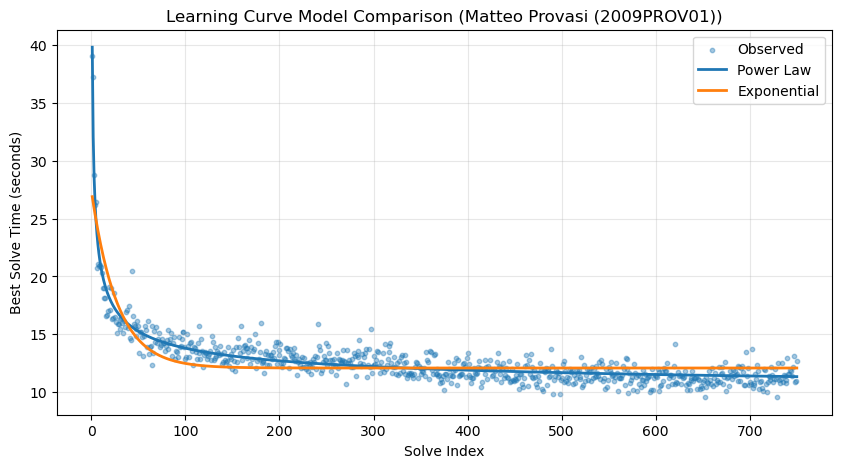

Best player for illustration: Matteo Provasi (2009PROV01)
Saved Figure 1 to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\figures\figure_01_best_player_learning_curve.png
Interpretation: the power-law model wins for every player in this sample, which supports gradual slowing rather than fixed-rate exponential convergence.


In [8]:
power_wins = (model_comparison['winner'] == 'power_law').sum()
exponential_wins = (model_comparison['winner'] == 'exponential').sum()
total_players = len(model_comparison)
power_win_rate = power_wins / total_players if total_players else float('nan')
mean_power_r2 = model_comparison['power_r2'].mean()
mean_exp_r2 = model_comparison['exp_r2'].mean()

rq1_table = pd.DataFrame([
    {'Metric': 'Players analyzed', 'Value': total_players},
    {'Metric': 'Power-law wins', 'Value': power_wins},
    {'Metric': 'Exponential wins', 'Value': exponential_wins},
    {'Metric': 'Power-law win rate', 'Value': round(power_win_rate, 3)},
    {'Metric': 'Mean power-law R²', 'Value': round(mean_power_r2, 3)},
    {'Metric': 'Mean exponential R²', 'Value': round(mean_exp_r2, 3)},
])

display(rq1_table)

best_learning_player = model_comparison.sort_values('delta_aic_abs', ascending=False).iloc[0]
best_player_id = best_learning_player['person_id']
best_player_name = best_learning_player['person_name']
best_trajectory = get_player_trajectory(best_player_id)
x = best_trajectory['seq_index'].to_numpy(dtype=float)
y = best_trajectory['average_seconds'].to_numpy(dtype=float)
power_params = get_fit_params(best_player_id, 'power_law')
exp_params = get_fit_params(best_player_id, 'exponential')
power_pred = power_law(x, power_params['a'], power_params['b'], power_params['c'])
exp_pred = exponential(x, exp_params['a'], exp_params['b'], exp_params['c'])

figure_1_path = figures_dir / 'figure_01_best_player_learning_curve.png'
fig, ax = plot_model_fits(x, y, power_pred, exp_pred, player_id=f'{best_player_name} ({best_player_id})')
fig.savefig(figure_1_path, dpi=200, bbox_inches='tight')
display(fig)
plt.close(fig)

print(f'Best player for illustration: {best_player_name} ({best_player_id})')
print(f'Saved Figure 1 to: {figure_1_path}')
print('Interpretation: the power-law model wins for every player in this sample, which supports gradual slowing rather than fixed-rate exponential convergence.')

## 2. Research Question 2

The second result asks whether residual fluctuations are random or persistent.

,Metric,Value
0,Mean Hurst exponent,0.674
1,Median Hurst exponent,0.651
2,Persistent players,100%
3,Mean DFA R²,0.983


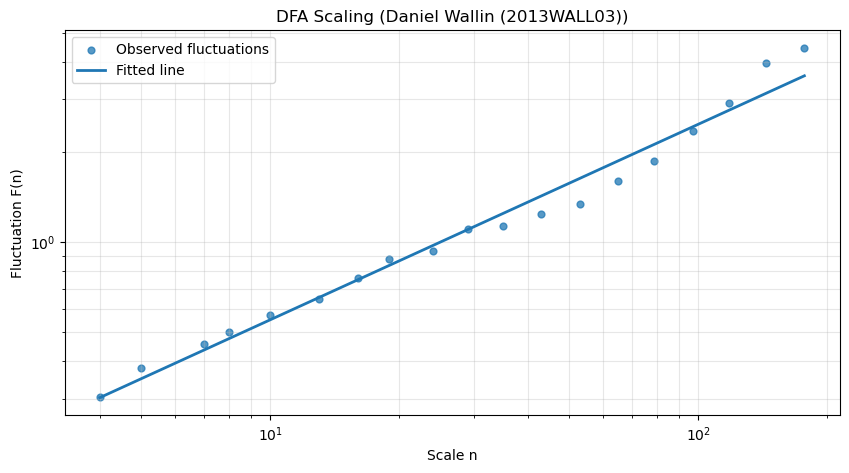

Representative DFA player: Daniel Wallin (2013WALL03)
Saved Figure 2 to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\figures\figure_02_representative_dfa_scaling.png
Interpretation: residuals are persistently correlated, so the learning process retains memory across long stretches of practice.


In [9]:
mean_hurst = dfa_results['hurst'].mean()
median_hurst = dfa_results['hurst'].median()
persistent_share = (dfa_results['noise_type'] == 'persistent').mean()
mean_dfa_r2 = dfa_results['dfa_r2'].mean()

rq2_table = pd.DataFrame([
    {'Metric': 'Mean Hurst exponent', 'Value': round(mean_hurst, 3)},
    {'Metric': 'Median Hurst exponent', 'Value': round(median_hurst, 3)},
    {'Metric': 'Persistent players', 'Value': f'{persistent_share:.0%}'},
    {'Metric': 'Mean DFA R²', 'Value': round(mean_dfa_r2, 3)},
])

display(rq2_table)

representative_dfa = dfa_results.iloc[(dfa_results['hurst'] - median_hurst).abs().argmin()]
rep_dfa_id = representative_dfa['person_id']
rep_dfa_model = representative_dfa['analysis_model']
rep_dfa_name = representative_dfa['person_name']
rep_residuals = residuals.loc[(residuals['person_id'] == rep_dfa_id) & (residuals['model'] == rep_dfa_model)].sort_values('seq_index').reset_index(drop=True)
hurst_result = calculate_hurst_exponent(rep_residuals['residual_seconds'].to_numpy(dtype=float))

figure_2_path = figures_dir / 'figure_02_representative_dfa_scaling.png'
fig, ax = plot_dfa_scaling(
    hurst_result['scales'],
    hurst_result['fluctuations'],
    slope=hurst_result['hurst'],
    intercept=hurst_result['intercept'],
    player_id=f'{rep_dfa_name} ({rep_dfa_id})'
)
fig.savefig(figure_2_path, dpi=200, bbox_inches='tight')
display(fig)
plt.close(fig)

print(f'Representative DFA player: {rep_dfa_name} ({rep_dfa_id})')
print(f'Saved Figure 2 to: {figure_2_path}')
print('Interpretation: residuals are persistently correlated, so the learning process retains memory across long stretches of practice.')

## 3. Research Question 3

The third result asks how the performance distribution changes as players approach mastery.

,Metric,Value
0,Mean early SD,3.136
1,Mean late SD,0.688
2,Variability ratio,0.267
3,Mean variability reduction,0.733
4,Wilcoxon p-value,0.002
5,Mean skewness early,3.965
6,Mean skewness late,0.677
7,Mean kurtosis early,30.939
8,Mean kurtosis late,1.640


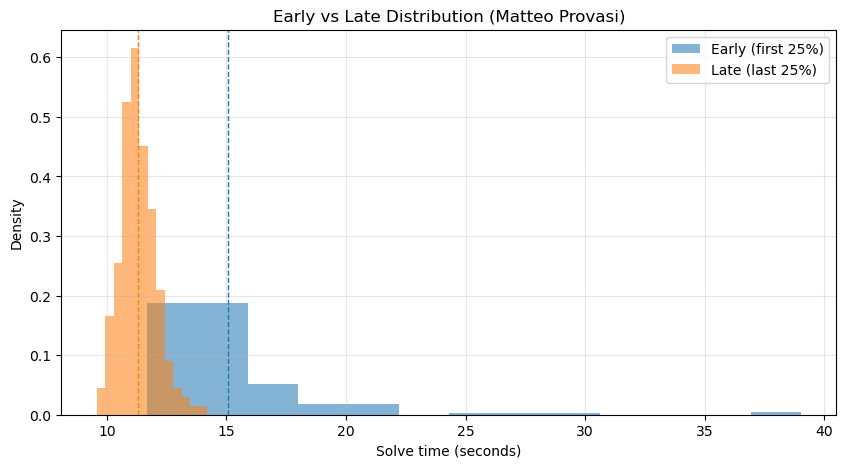

Representative distribution player: Matteo Provasi (2009PROV01)
Saved Figure 3 to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\figures\figure_03_representative_distribution_overlay.png
Interpretation: late-career distributions are narrower, less skewed, and less heavy-tailed, which indicates increasingly stable execution.


In [10]:
mean_std_early = float(distribution_summary.loc[distribution_summary['metric'] == 'mean_std_early', 'value'].iloc[0])
mean_std_late = float(distribution_summary.loc[distribution_summary['metric'] == 'mean_std_late', 'value'].iloc[0])
mean_std_ratio = float(distribution_summary.loc[distribution_summary['metric'] == 'mean_std_ratio', 'value'].iloc[0])
mean_variability_reduction_pct = float(distribution_summary.loc[distribution_summary['metric'] == 'mean_variability_reduction_pct', 'value'].iloc[0])
wilcoxon_pvalue = float(distribution_summary.loc[distribution_summary['metric'] == 'wilcoxon_pvalue', 'value'].iloc[0])
mean_skew_early = variability_comparison['skewness_early'].mean()
mean_skew_late = variability_comparison['skewness_late'].mean()
mean_kurt_early = variability_comparison['kurtosis_early'].mean()
mean_kurt_late = variability_comparison['kurtosis_late'].mean()

rq3_table = pd.DataFrame([
    {'Metric': 'Mean early SD', 'Value': round(mean_std_early, 3)},
    {'Metric': 'Mean late SD', 'Value': round(mean_std_late, 3)},
    {'Metric': 'Variability ratio', 'Value': round(mean_std_ratio, 3)},
    {'Metric': 'Mean variability reduction', 'Value': round(mean_variability_reduction_pct, 3)},
    {'Metric': 'Wilcoxon p-value', 'Value': round(wilcoxon_pvalue, 4)},
    {'Metric': 'Mean skewness early', 'Value': round(mean_skew_early, 3)},
    {'Metric': 'Mean skewness late', 'Value': round(mean_skew_late, 3)},
    {'Metric': 'Mean kurtosis early', 'Value': round(mean_kurt_early, 3)},
    {'Metric': 'Mean kurtosis late', 'Value': round(mean_kurt_late, 3)},
])

display(rq3_table)

representative_distribution = variability_comparison.iloc[(variability_comparison['std_ratio'] - variability_comparison['std_ratio'].median()).abs().argmin()]
rep_dist_id = representative_distribution['person_id']
rep_dist_name = representative_distribution['person_name']
rep_dist_trajectory = get_player_trajectory(rep_dist_id)
n_obs = len(rep_dist_trajectory)
phase_n = n_obs // 4
early_values = rep_dist_trajectory.iloc[:phase_n]['average_seconds'].to_numpy(dtype=float)
late_values = rep_dist_trajectory.iloc[-phase_n:]['average_seconds'].to_numpy(dtype=float)
bins = max(12, int(np.sqrt(phase_n)))

figure_3_path = figures_dir / 'figure_03_representative_distribution_overlay.png'
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(early_values, bins=bins, alpha=0.55, label='Early (first 25%)', density=True)
ax.hist(late_values, bins=bins, alpha=0.55, label='Late (last 25%)', density=True)
ax.axvline(np.mean(early_values), linestyle='--', color='C0', linewidth=1)
ax.axvline(np.mean(late_values), linestyle='--', color='C1', linewidth=1)
ax.set_xlabel('Solve time (seconds)')
ax.set_ylabel('Density')
ax.set_title(f'Early vs Late Distribution ({rep_dist_name})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.savefig(figure_3_path, dpi=200, bbox_inches='tight')
display(fig)
plt.close(fig)

print(f'Representative distribution player: {rep_dist_name} ({rep_dist_id})')
print(f'Saved Figure 3 to: {figure_3_path}')
print('Interpretation: late-career distributions are narrower, less skewed, and less heavy-tailed, which indicates increasingly stable execution.')

## Main Findings

1. Individual learning trajectories are better described by power-law dynamics than exponential decay.
2. Residual fluctuations exhibit persistent temporal correlations, with mean Hurst exponent around 0.67.
3. Performance variability drops sharply as players approach mastery, and distribution shapes become tighter and less extreme.

Together, these results suggest that skill acquisition is a gradual, memory-dependent process characterized by long-term improvement and increasingly stable execution.